# Exercițiul 1:

Citirea unei liste dintr-un fișier `.csv` și selectarea unui număr predeterminat de studenți care nu au prezentat încă o temă, fără repetiție.

## Pasul 1: Pregătirea Datelor și Importul Bibliotecilor

Importăm bibliotecile necesare și încărcăm fișierul `studenti.csv`.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Calea către fișierul CSV din folderul curent
cale_csv = 'studenti.csv'

# Citim fișierul CSV
df_studenti = pd.read_csv(cale_csv)

# studenții care nu au prezentat încă tema
studenti_eligibili = df_studenti[df_studenti['a_prezentat'] == False]['nume_prenume'].tolist()

print(f"Total studenți eligibili identificați: {len(studenti_eligibili)}")
print("Primii 3 studenți din listă:", studenti_eligibili[:3])

Total studenți eligibili identificați: 10
Primii 3 studenți din listă: ['Popescu Andrei', 'Ionescu Maria', 'Georgescu Vlad']


## Pasul 2: Extragerea Eșantionului Fără Repetiție

Utilizăm funcția `np.random.choice` cu parametrul `replace=False` din biblioteca NumPy pentru a garanta extragerea fără repunere.

In [53]:
# Numarul prestabilit de studenti
k = 3

# Verificăm validitatea valorii k
if k > len(studenti_eligibili):
    print(f"Eroare: k ({k}) depășește numărul total de studenți eligibili ({len(studenti_eligibili)})!")
else:
    # Extragere fara repetitie
    studenti_selectati = np.random.choice(studenti_eligibili, size=k, replace=False)

    print(f"\n--- Studenții extrași pentru prezentare (k = {k}) ---")
    for idx, student in enumerate(studenti_selectati, start=1):
        print(f"{idx}. {student}")


--- Studenții extrași pentru prezentare (k = 3) ---
1. Stoica Gabriel
2. Calugaru Dumitrita
3. Papadie Alexia


### Explicații:
* **Filtrarea:** Am extras doar înregistrările unde starea `a_prezentat` este `False`.
* **Eșantionarea fără repetiție:** Parametrul `replace=False` asigură că odată extras un student, acesta este scos din urna și nu poate apărea de două ori în selecție.

# Exercițiul 2:

Regulile:
* La fiecare pas aruncăm o monedă.
* Dacă pică **stemă**, cel de-al doilea jucător aruncă cu un zar cu 6 fețe și îi dă primului jucător suma $(z - 3)\$$. Jocul se oprește.
* Dacă pică **ban**, primul jucător îi dă celui de-al doilea suma de $0.5\$$ ($-0.5\$$ pentru primul jucător), iar jocul continuă.

## Punctul a: Distribuția lui N

Numărul de pași $N$ este numărul de încercări Bernoulli independente până la obținerea primului succes (prima stema).

Variabila aleatoare $N$ urmează o **distributie Geometrica**:
$$N \sim \text{Geometric}(p)$$
unde $p$ este probabilitatea de a obține stemă la o aruncare ($p = 0.5$ pentru o monedă echilibrată).

## Punctul b: Simularea unui Singur Joc

Definim funcția care simulează o rundă completă a jocului până la oprire și returnează pașii $N$ și suma finală $S$.

In [54]:
def simuleaza_un_joc(p_stema=0.5):
    """
    Simulează un joc complet până la prima apariție a stemei.
    p_stema: probabilitatea de a pica stemă
    Returnează: N (număr de pași) și S (suma netă primită de Jucătorul 1)
    """
    N = 0
    S = 0.0
    
    while True:
        N += 1
        # 1 = Stemă (cu probabilitatea p_stema), 0 = Ban (cu 1 - p_stema)
        moneda = np.random.choice([1, 0], p=[p_stema, 1 - p_stema])
        
        if moneda == 1:
            # se dă cu zarul (z între 1 și 6) și jocul se încheie
            z = np.random.randint(1, 7)
            S += (z - 3)
            break
        else:
            # Jucătorul 1 plătește 0.5$
            S -= 0.5
            
    return N, S

n_exemplu, s_exemplu = simuleaza_un_joc(p_stema=0.5)
print(f"Rezultat joc demonstrativ (p=0.5):")
print(f"Număr pași (N): {n_exemplu}")
print(f"Suma finală (S): {s_exemplu} $")

Rezultat joc demonstrativ (p=0.5):
Număr pași (N): 3
Suma finală (S): -2.0 $


## Punctul c:

Simulăm $100.000$ de jocuri pentru o monedă corectă ($p = 0.5$), calculăm media sumei $S$ și afișăm distribuția acesteia printr-o histograma.

Rezultate pentru p = 0.5 (100000 simulări):
Media estimata a sumei S: -0.0044 $
Media numărului de pasi N: 2.0056


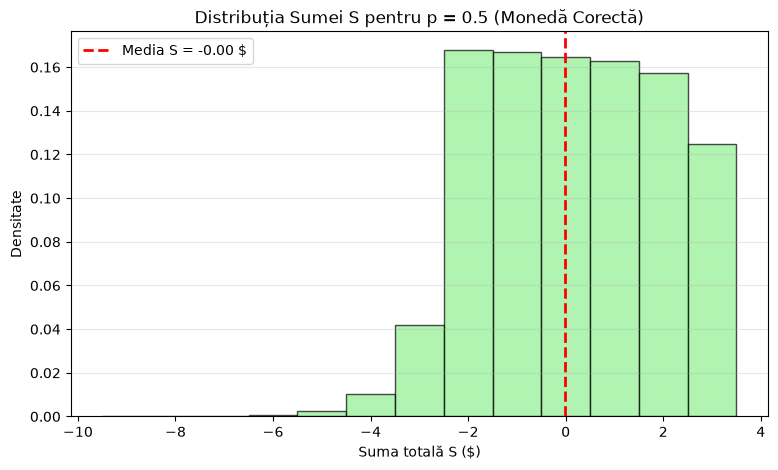

In [55]:
numar_simulari = 100000
np.random.seed(42)

sume_S = []
pasi_N = []

for _ in range(numar_simulari):
    pasi, castig = simuleaza_un_joc(p_stema=0.5)
    pasi_N.append(pasi)
    sume_S.append(castig)

media_S = np.mean(sume_S)
media_N = np.mean(pasi_N)

print(f"Rezultate pentru p = 0.5 ({numar_simulari} simulări):")
print(f"Media estimata a sumei S: {media_S:.4f} $")
print(f"Media numărului de pasi N: {media_N:.4f}")

# histograma
plt.figure(figsize=(9, 5))
bins = np.arange(min(sume_S) - 0.5, max(sume_S) + 1.5, 1)
plt.hist(sume_S, bins=bins, density=True, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(media_S, color='red', linestyle='--', linewidth=2, label=f'Media S = {media_S:.2f} $')

plt.title('Distribuția Sumei S pentru p = 0.5 (Monedă Corectă)')
plt.xlabel('Suma totală S ($)')
plt.ylabel('Densitate')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Interpretare pentru punctul c:
* **Media teoretică pentru N:** $E[N] = \frac{1}{p} = \frac{1}{0.5} = 2$ pași.
* **Media teoretică pentru S:** La fiecare joc avem în medie $E[N] - 1 = 1$ bani (pierdere $-0.5\$$) și o aruncare de zar cu media $E[z] = 3.5$, generând un câștig de $3.5 - 3 = +0.5\$$. 
* Suma medie totală este $0.5 - 0.5 = 0\$$

## Punctul d: Măsluită (p = 0.3 vs p = 0.7)

Refacem analiza pentru cazurile în care moneda este dezechilibrată:
1. $p = 0.3$ (stema apare mai greu, jocul durează mai mult)
2. $p = 0.7$ (stema apare repede, jocul se încheie rapid)

Pentru p = 0.3: Media estimata a sumei S este -0.6620 $
Pentru p = 0.7: Media estimata a sumei S este 0.2785 $


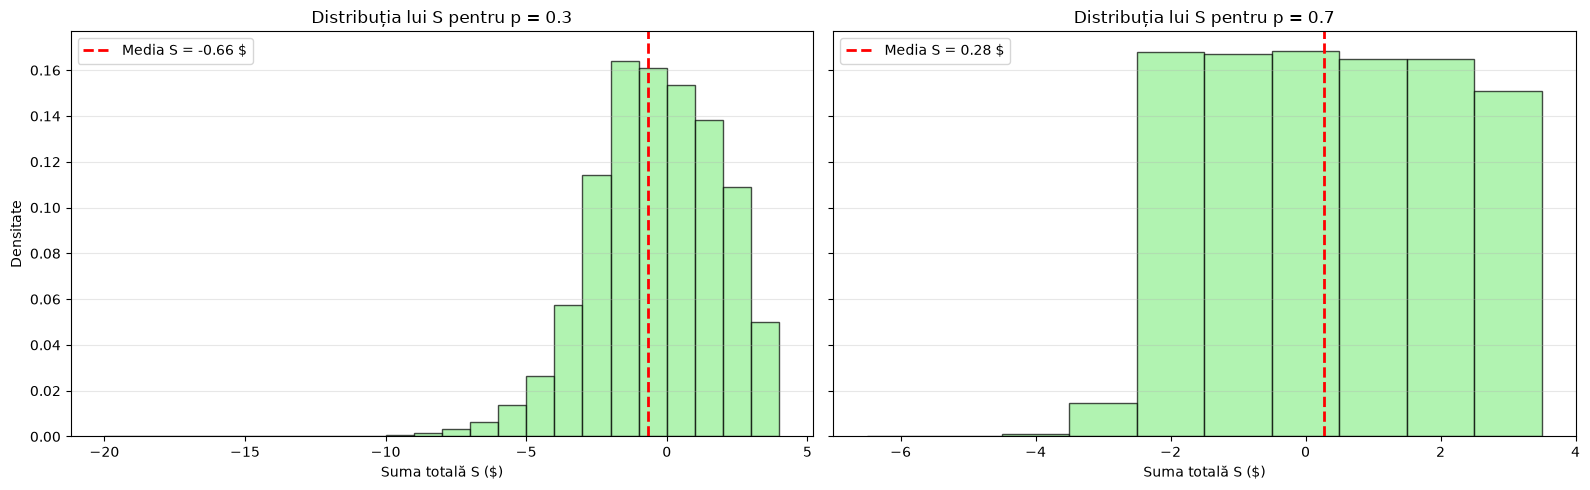

In [56]:
p_valori = [0.3, 0.7]
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for idx, p in enumerate(p_valori):
    sume_p = [simuleaza_un_joc(p_stema=p)[1] for _ in range(numar_simulari)]
    media_p = np.mean(sume_p)
    
    print(f"Pentru p = {p}: Media estimata a sumei S este {media_p:.4f} $")
    
    ax = axes[idx]
    bins = np.arange(min(sume_p) - 0.5, max(sume_p) + 1.5, 1)
    ax.hist(sume_p, bins=bins, density=True, color='lightgreen', edgecolor='black', alpha=0.7)
    ax.axvline(media_p, color='red', linestyle='--', linewidth=2, label=f'Media S = {media_p:.2f} $')
    
    ax.set_title(f'Distribuția lui S pentru p = {p}')
    ax.set_xlabel('Suma totală S ($)')
    if idx == 0:
        ax.set_ylabel('Densitate')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretare pentru punctul d:
* **Pentru $p = 0.3$:** Numărul mediu de pași crește la $E[N] = \frac{1}{0.3} \approx 3.33$. Deoarece apar mai mulți bani înainte de prima stemă, Jucătorul 1 plătește de mai multe ori suma de $0.5\$$, ceea ce duce la o valoare medie finală negativă (aproximativ **$-0.67\$$**).
* **Pentru $p = 0.7$:** Numărul mediu de pași scade la $E[N] = \frac{1}{0.7} \approx 1.43$. Stema apare aproape imediat, Jucătorul 1 pierde rar bani pe parcurs, iar câștigul de la zar domină, ducând media finală la o valoare pozitivă (aproximativ **$+0.28\$$**).

# Exercițiul 3: 

Avem trei frizeri ale căror rate de servire sunt $\lambda_1 = 3\text{ h}^{-1}$, $\lambda_2 = 6\text{ h}^{-1}$ și $\lambda_3 = 4\text{ h}^{-1}$. Timpul de servire al fiecărui frizer urmează o distribuție exponențială $\text{Exp}(\lambda_i)$.

### De ce probabilitățile de preluare sunt $3/13$, $6/13$ și $4/13$?
* Rata totală de servire a frizeriei este suma ratelor individuale:
  $$\Lambda = \lambda_1 + \lambda_2 + \lambda_3 = 3 + 6 + 4 = 13\text{ clienți/oră}$$
* Probabilitatea ca un client să fie preluat de frizerul $i$ este proporțională cu viteza sa de lucru:
  $$P(\text{Frizer } i) = \frac{\lambda_i}{\Lambda}$$
  Frizerul mai rapid finalizează mai repede și preia proporțional mai mulți clienți.